ARTI308 - Machine Learning


# Lab 5: Feature Engineering (Classification)
## Order Status Prediction using a Talabat-style Orders Dataset

### Lab focus
This dataset is already clean (no missing values, no duplicate rows, consistent data types). 

In this lab, we focus on **feature engineering** for a classification task.

### Objective
Build a baseline model to predict `Order_Status` (Delivered, Cancelled, In Transit) and learn how feature engineering choices affect model performance and feature importance. 

## 1. Setup and imports

In [76]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [77]:

DATA_PATH = "talabat_enhanced_orders2.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,2025-06-11 14:58:00,21,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,2025-06-08 20:49:00,36,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,2025-06-07 04:20:00,51,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,2025-06-09 21:30:00,41,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,2025-06-08 12:33:00,28,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online
5,88329,U3379,454,90,Sandwich,1,125.68,2025-06-02 04:02:00,2025-06-02 04:33:00,31,Alexandria,Cash,Delivered,Car,31.180300,29.922967,31.180552,29.899449,31.211355,29.929651,2.242070,Low,Online
6,79499,U3029,168,479,Sushi,2,243.62,2025-06-15 01:06:00,2025-06-15 01:59:00,53,Giza,Credit Card,Delivered,Motorbike,30.013826,31.215348,30.020233,31.228303,29.995995,31.212204,1.437552,Low,Online
7,27325,U3674,473,321,Fried Chicken,1,149.87,2025-06-04 01:02:00,2025-06-04 01:53:00,51,Tanta,Cash,Cancelled,Car,30.794454,30.998586,30.791487,31.002607,30.799764,31.006845,0.506267,Low,Online
8,73621,U8696,704,42,Pasta,4,562.32,2025-06-14 06:45:00,2025-06-14 07:33:00,48,Zagazig,Credit Card,Delivered,Car,30.573653,31.508104,30.602105,31.519432,30.587649,31.500689,3.336044,Low,Online
9,18180,U3260,458,183,Pasta,5,194.95,2025-06-03 02:50:00,2025-06-03 03:15:00,25,Alexandria,Cash,Delivered,Motorbike,31.193297,29.906175,31.187237,29.913781,31.202042,29.926440,0.988472,Low,Online


In [78]:
df.shape

(25000, 23)

The first rows confirm that the dataset loaded correctly.  
Each row represents one food delivery order, including information about the customer, restaurant, driver, and order outcome (`Order_Status`).

## 3. Quick dataset checks

In [79]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (25000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


We confirm the dataset is clean: no missing values and no duplicated rows.  
Therefore, we will spend our effort on feature engineering rather than cleaning.

## 4. Target variable and class balance

In [ ]:
target_col = "Order_Status"
df[target_col].value_counts()

Order_Status
Delivered     10197
Cancelled      9812
In Transit     4991
Name: count, dtype: int64

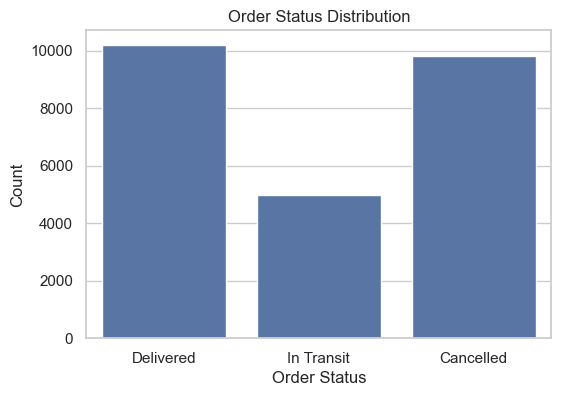

In [81]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

This bar chart shows whether the classes are balanced.  
If one class dominates, the model may learn to predict that class more often, so we must interpret accuracy carefully and also look at the confusion matrix.

## 5. Identify feature types

In [82]:
df.dtypes

Order_ID                       int64
User_ID                       object
Restaurant_ID                  int64
Driver_ID                      int64
Item_Name                     object
Quantity                       int64
Total_Price                  float64
Order_Time                    object
Delivery_Time                 object
Delivery_Duration_Minutes      int64
City                          object
Payment_Method                object
Order_Status                  object
Driver_Vehicle                object
Restaurant_Lat               float64
Restaurant_Lon               float64
Customer_Lat                 float64
Customer_Lon                 float64
Driver_Lat                   float64
Driver_Lon                   float64
Delivery_Distance_km         float64
Traffic_Level                 object
Driver_Availability           object
dtype: object

We have a mixture of numerical features (e.g., `Quantity`, `Total_Price`, distances) and categorical features (e.g., `City`, `Payment_Method`, `Traffic_Level`).  
This is a common real-world situation where feature engineering and encoding become essential.


## 6. Leakage awareness (important)

When designing a prediction task, we must avoid using features that would not be available at prediction time.

For example, if we want to predict the order status **right after the customer places the order**, we should not use:
- `Delivery_Time` (known only later)
- `Delivery_Duration_Minutes` (known only after delivery)

In this lab, we will **exclude** obvious leakage features and focus on information that is typically available early in the order lifecycle.

In [83]:
drop_cols = ["Delivery_Time", "Delivery_Duration_Minutes"]

# keep only existing columns
drop_cols = [c for c in drop_cols if c in df.columns]

# drop from dataframe
df = df.drop(columns=drop_cols)

## 7. Feature engineering

### 7.1 Time-based features from `Order_Time`
We convert `Order_Time` into a datetime, then extract:
- hour of day  
- day of week  
- weekend flag  
- peak hour flag (example rule: lunch and dinner periods)


In [84]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)


,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-11 14:37:00,14,2,0,1
1,2025-06-08 20:13:00,20,6,1,1
2,2025-06-07 03:29:00,3,5,1,0
3,2025-06-09 20:49:00,20,0,0,1
4,2025-06-08 12:05:00,12,6,1,1
5,2025-06-02 04:02:00,4,0,0,0
6,2025-06-15 01:06:00,1,6,1,0
7,2025-06-04 01:02:00,1,2,0,0
8,2025-06-14 06:45:00,6,5,1,0
9,2025-06-03 02:50:00,2,1,0,0


We transformed the original timestamp into multiple meaningful features.  
Models often learn better from these engineered features than from raw timestamps.

### 7.2 Price-based features
We create a feature that captures the price per item:
`price_per_item = Total_Price / Quantity`

This can help the model differentiate between an expensive order with few items and a cheaper order with many items.

In [85]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)

,Quantity,Total_Price,price_per_item
0,5,305.65,61.13
1,4,446.40,111.60
2,3,394.50,131.50
3,4,139.20,34.80
4,2,207.02,103.51
5,1,125.68,125.68
6,2,243.62,121.81
7,1,149.87,149.87
8,4,562.32,140.58
9,5,194.95,38.99


`price_per_item` is a derived feature that may reflect restaurant type, item category, or order complexity.  
It is an example of business-driven feature engineering.

### 7.3 Reducing high-cardinality categories 
#### (example: `Item_Name`)
`Item_Name` may have many unique values. If we one-hot encode all items, the feature space becomes huge.

A common feature engineering approach is to keep the most frequent categories and map the rest to `Other`.


In [86]:
if "Item_Name" in df_fe.columns:
    top_k = 10
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")

Unique Item_Name: 9
Unique Item_Name_reduced: 9


We reduced the cardinality of a text category feature.  
This often improves model stability and reduces overfitting, especially for baseline models.

## 8. Discretization (binning)

Discretization converts a continuous numerical feature into categories (bins).  
This can help some models capture non-linear relationships, and it also improves interpretability.

Here we discretize `Total_Price` into simple tiers.


In [87]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)

,Total_Price,price_tier
0,305.65,high
1,446.40,high
2,394.50,high
3,139.20,medium
4,207.02,medium
5,125.68,medium
6,243.62,medium
7,149.87,medium
8,562.32,very_high
9,194.95,medium


`price_tier` groups numeric values into understandable categories.  
This may help capture patterns such as higher cancellation rates for very expensive orders, if such a trend exists.

In [88]:
df_fe.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,Item_Name_reduced,price_tier
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online,14,2,0,1,61.13,Sushi,high
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online,20,6,1,1,111.60,Pizza,high
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online,3,5,1,0,131.50,Koshary,high
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online,20,0,0,1,34.80,Burger,medium
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online,12,6,1,1,103.51,Salad,medium


## 9. Prepare features for modeling

We now select our predictors.

We will drop:
- IDs that do not represent meaningful signals by themselves
- Obvious leakage features (`Delivery_Time`, `Delivery_Duration_Minutes`)

We will keep:
- early-available numeric and categorical variables
- engineered features

In [89]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID",
    "Order_Time","Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
X.head()

X shape: (25000, 21)
y shape: (25000,)


,Quantity,Total_Price,City,Payment_Method,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,Item_Name_reduced,price_tier
0,5,305.65,Giza,Wallet,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online,14,2,0,1,61.13,Sushi,high
1,4,446.40,Cairo,Cash,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online,20,6,1,1,111.60,Pizza,high
2,3,394.50,Mansoura,Credit Card,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online,3,5,1,0,131.50,Koshary,high
3,4,139.20,Tanta,Wallet,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online,20,0,0,1,34.80,Burger,medium
4,2,207.02,Tanta,Credit Card,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online,12,6,1,1,103.51,Salad,medium


We prepared a feature matrix `X` and a target vector `y`.  
The feature matrix includes engineered features such as time-based indicators, price per item, and reduced item category.

## 10. Split into train and test sets

In [90]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (20000, 21)
Test size: (5000, 21)


We use stratified splitting to keep class proportions similar in train and test sets.  
This makes evaluation more reliable for classification problems with imbalanced classes.
## 11. Encoding

### Why encoding?
Machine learning models require numerical input.  
Categorical variables must be converted into numbers. Here we use **One-Hot Encoding** for nominal categories.

### Why Random Forest for this lab?
We use Random Forest as a baseline because:
- it handles mixed features well
- it is robust for teaching purposes
- it provides feature importance to help us interpret engineered features


In [91]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()


print("Categorical columns:\n", categorical_cols,'\n')
print("Numeric columns:\n", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns:
 ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier'] 

Numeric columns:
 ['Quantity', 'Total_Price', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item']


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocess', ...), ('rf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the outp

## 12. Train the model and evaluate

In [92]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.3936

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.38      0.43      0.41      1963
   Delivered       0.40      0.55      0.46      2039
  In Transit       0.17      0.00      0.00       998

    accuracy                           0.39      5000
   macro avg       0.32      0.33      0.29      5000
weighted avg       0.35      0.39      0.35      5000



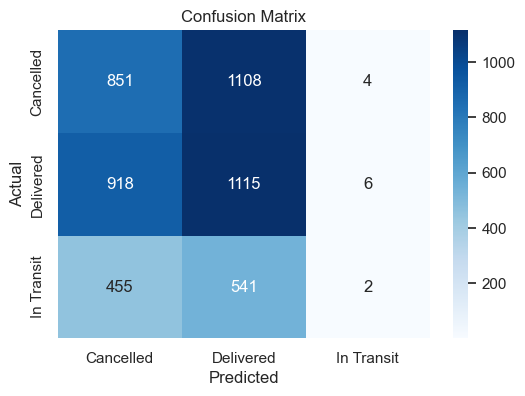

In [93]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Accuracy gives a general sense of performance, but the classification report is more informative.  
Precision answers: when the model predicts a class, how often is it correct?  
Recall answers: out of all real cases of a class, how many did the model find?

The confusion matrix shows which classes the model confuses most often.

## 13. Feature importance (What mattered the most?)

Random Forest provides a built-in feature importance score.  
Because we used one-hot encoding, each categorical value becomes its own feature.  
We will extract the final feature names and plot the top importances.

In [94]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
39,Delivery_Distance_km,0.075183
44,price_per_item,0.073257
37,Driver_Lat,0.072854
38,Driver_Lon,0.072853
36,Customer_Lon,0.072426
35,Customer_Lat,0.072128
34,Restaurant_Lon,0.072122
33,Restaurant_Lat,0.072000
32,Total_Price,0.071673
40,order_hour,0.051503


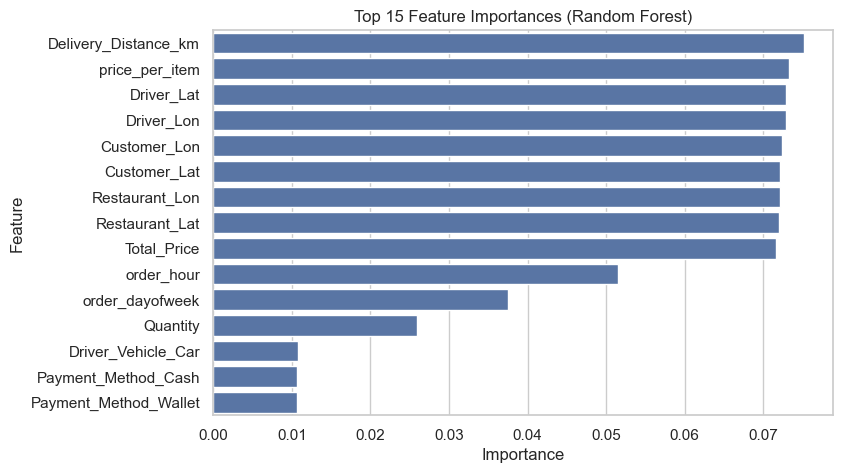

In [95]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

This chart helps us understand which engineered and original features contributed most to predicting `Order_Status`.  
A high importance score suggests the feature provides useful signal, but it does not automatically imply a causal relationship.

### Task
using the same dataset, change `top_k` in `Item_Name_reduced` (for example 3, 5, 6) and compare:
- accuracy
- top feature importances

In [102]:
for k in [6, 5, 3]:
    print(f"\n==============================")
    print(f"Results fro top_k = {k}")
    print(f"\n==============================")

    # changing unber of items with k
    top_items = df_fe["Item_Name"].value_counts().head(k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")

    # rebuliding X and y then and spliting them
    X = df_fe.drop(columns=drop_cols + [target_col])    
    y = df_fe[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify=y)

    # train the model and outputing report
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("accuracy_score: ", round(accuracy_score(y_test, y_pred), 4))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    print("-" * 40)

    # get importance of features
    ohe = model.named_steps["preprocess"].named_transformers_["cat"]
    cat_feature_names = ohe.get_feature_names_out(categorical_cols)
    all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

    print("Top Features:")
    print(fi.head(15).to_string(index=False))



Results fro top_k = 6

accuracy_score:  0.3908

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.38      0.46      0.42      1963
   Delivered       0.40      0.52      0.45      2039
  In Transit       0.19      0.00      0.01       998

    accuracy                           0.39      5000
   macro avg       0.32      0.33      0.29      5000
weighted avg       0.35      0.39      0.35      5000

----------------------------------------
Top Features:
              feature  importance
 Delivery_Distance_km    0.075183
       price_per_item    0.073257
           Driver_Lat    0.072854
           Driver_Lon    0.072853
         Customer_Lon    0.072426
         Customer_Lat    0.072128
       Restaurant_Lon    0.072122
       Restaurant_Lat    0.072000
          Total_Price    0.071673
           order_hour    0.051503
      order_dayofweek    0.037521
             Quantity    0.025972
   Driver_Vehicle_Car    0.010783
  Payment_Method

As shown in the output feature importance have not change. Therefore, Order status is not affected by the type of item but with how far drivers have to travel or the price of item.

In addtion, By aggressively grouping 6 of the 9 food items into a single "Other" category, you simplified the data. When top_k was higher (5 or 6), the model was likely getting distracted by rare food items and learning random noise. Shrinking it to 3 removed that distraction.

